In [15]:
import pandas as pd
import importlib
import funciones as func #Tener funciones.py en mismo directorio. Tiene las funciones usadas para procesar un df
importlib.reload(func)

<module 'funciones' from 'c:\\Users\\dafyd\\Documents\\Escuela\\2025\\semestre 1\\TD6\\TP2\\last_day\\funciones.py'>

In [16]:
data = pd.read_csv('../competition_data.csv')
submission = pd.read_csv('../submission.csv')
submission_aux = pd.read_csv('../submission.csv')

In [17]:
data = pd.read_csv('../competition_data.csv')

In [18]:
import csv
f = open('../uri_to_duration.csv', 'r')
diccionario = {}
for line in csv.DictReader(f):
    diccionario[line['uri']] = float(line['duration'])
f.close()
diccionario

{'spotify:track:3jFfr89lnSmb4QBtfG8JBP': 187120.0,
 'spotify:track:09TTeexnlKewZdjOak2sV2': 292573.0,
 'spotify:track:0G3fbPbE1vGeABDEZF0jeG': 495400.0,
 'spotify:track:1NXvuBAq48QrxRFQZVmORQ': 430960.0,
 'spotify:track:2gYJY0sIx1ErgTIha2nPRg': 214848.0,
 'spotify:track:0njXuAkJVSpptzKniMBtIZ': 405499.0,
 'spotify:track:7Kszjzps0xbQXyo1pO4KfE': 331360.0,
 'spotify:track:39KmBOGkD1ztCbVeo2uspA': 277560.0,
 'spotify:track:0UAEHlFR79k9CJvknSGUNf': 215040.0,
 'spotify:track:1sWeSMifj6Z6kZyI6z3bRc': 171040.0,
 'spotify:track:0nLiqZ6A27jJri2VCalIUs': 388266.0,
 'spotify:track:1Ig4pCPanhzXl7C86MmBUc': 161133.0,
 'spotify:track:0WtDGnWL2KrMCk0mI1Gpwz': 326933.0,
 'spotify:track:326HJ8o8XJff8dSZOwe4GS': 288586.0,
 'spotify:track:1bSpwPhAxZwlR2enJJsv7U': 229120.0,
 'spotify:track:5luOvrlnzfvJQdQjrScVj4': 249500.0,
 'spotify:track:1SJtlNRJDeYHioymcvsqev': 216391.0,
 'spotify:track:06pjQCIybMiGrgtHODGa2m': 225906.0,
 'spotify:track:6eJlEcRmeyQfTlDQBDyqkW': 156680.0,
 'spotify:track:6A64S6NPQwA5KIQ

In [19]:
data = func.procesar_df(data, diccionario)

In [20]:
import xgboost as xgb

drop_cols = [
    'Unnamed: 0','ts','TARGET', 'platform', 'reason_start',
    'master_metadata_track_name',
    'master_metadata_album_artist_name',
    'master_metadata_album_album_name',
    'spotify_track_uri','platform'
]
clf_xgb = xgb.XGBClassifier(objective = 'binary:logistic',
                            seed = 42,
                            eval_metric = 'auc')
clf_xgb.fit(data.drop(columns=drop_cols), data['TARGET'])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

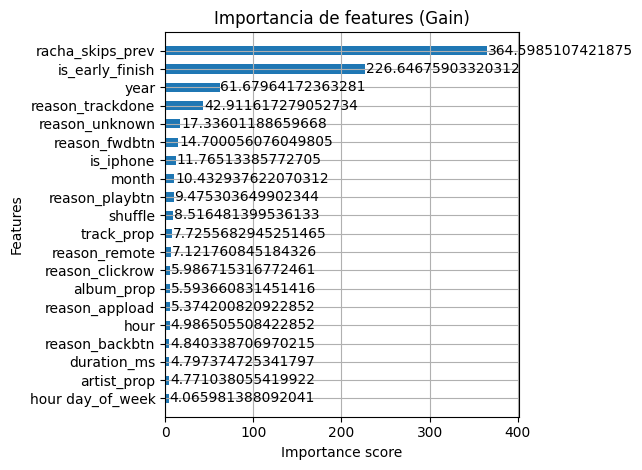

In [21]:
import matplotlib.pyplot as plt
xgb.plot_importance(clf_xgb, importance_type='gain', max_num_features=20, height=0.5)
plt.title("Importancia de features (Gain)")
plt.tight_layout()
plt.show()

In [23]:
data = pd.read_csv('../competition_data.csv')

In [24]:
submission = func.procesar_df_2(submission, diccionario)

In [25]:
union = pd.concat([data, submission_aux], axis=0)

In [26]:
union.columns

Index(['Unnamed: 0', 'ts', 'username', 'platform', 'conn_country',
       'user_agent_decrypted', 'master_metadata_track_name',
       'master_metadata_album_artist_name', 'master_metadata_album_album_name',
       'spotify_track_uri', 'reason_start', 'shuffle', 'TARGET'],
      dtype='object')

In [27]:
union = func.procesar_df(union, diccionario)

In [28]:
submission = submission.merge(
    union[['Unnamed: 0', 'is_early_finish', 'racha_skips_prev']],
    on='Unnamed: 0',
    how='left'
)

In [ ]:
submission = submission[['Unnamed: 0', 'ts', 'platform', 'master_metadata_track_name',
       'master_metadata_album_artist_name', 'master_metadata_album_album_name',
       'spotify_track_uri', 'reason_start', 'shuffle', 'hour',
       'day_of_week', 'month', 'year', 'is_iphone', 'duration_ms',
       'is_early_finish', 'racha_skips_prev', 'reason_appload', 'reason_backbtn',
       'reason_clickrow', 'reason_fwdbtn', 'reason_playbtn', 'reason_remote',
       'reason_trackdone', 'reason_trackerror', 'reason_unknown', 'track_prop',
       'artist_prop', 'album_prop', 'hour day_of_week']]

In [ ]:
drop_cols = [
    'Unnamed: 0','ts', 'platform', 'reason_start',
    'master_metadata_track_name',
    'master_metadata_album_artist_name',
    'master_metadata_album_album_name',
    'spotify_track_uri','platform'
]

prediccion_submmit = clf_xgb.predict_proba(submission.drop(columns=drop_cols))[:, 1]

In [ ]:
results = pd.DataFrame({'ID': submission['Unnamed: 0'], 'TARGET': prediccion_submmit})
results = results.set_index('ID').loc[submission_aux['Unnamed: 0']].reset_index()
results.to_csv('submission19.csv', index=False)